## Imports

Make sure you append the correct path to where the folder containing the packages are located.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mypackages.edp_processing import ImageAnalysis, ImageProcessing, peak_calibration

## Loading the data

There is a variety of ways of loading the data into the scripts, here we opt to import the images as .tif using the ImageProcessing class. The only requirement is that the data is loaded as numpy arrays of 16 bit datatype. 

Tiff images

In [96]:
from tifffile import tifffile
directory = r"Z:\ActualWork\Victor\raw_data\spirit\Au\20250910\b2_1s.tif"
img = tifffile.imread(directory)

Load .ser data

In [2]:
import hyperspy.api as hs

directory = r"E:\data_processing\data\raw\ED\In2O3"
names = [x for x in os.listdir(directory) if x.endswith('.ser')] 

file_path = os.path.join(directory, names[0])
data = hs.load(file_path, signal_type='diffraction', lazy=True)
imgs = np.array(data)
img= imgs.sum(axis=0)
del imgs

WARNING | Hyperspy | `signal_type='diffraction'` not understood. See `hs.print_known_signal_types()` for a list of installed signal types or https://github.com/hyperspy/hyperspy-extensions-list for the list of all hyperspy extensions providing signals. (hyperspy.io:745)


Load .dm4 data

In [8]:
import dm4

# --- Define file paths ---
input_path = "/home/ABTLUS/victor.secco/data_processing/ED/MnO/F-MnO-ODE-S2-PDF_2.dm4"
npy_output_path = "/home/ABTLUS/victor.secco/data_processing/ED/MnO/F-MnO-ODE-S2-PDF_2.npy"
tif_output_path = "/home/ABTLUS/victor.secco/data_processing/ED/MnO/F-MnO-ODE-S2-PDF_2.tif"

# --- Open .dm4 file and extract image data ---
with dm4.DM4File.open(input_path) as dm4file:
    tags = dm4file.read_directory()

    image_data_tag = tags.named_subdirs['ImageList'].unnamed_subdirs[1].named_subdirs['ImageData']
    image_tag = image_data_tag.named_tags['Data']

    XDim = dm4file.read_tag_data(image_data_tag.named_subdirs['Dimensions'].unnamed_tags[0])
    YDim = dm4file.read_tag_data(image_data_tag.named_subdirs['Dimensions'].unnamed_tags[1])

    image_array = np.array(dm4file.read_tag_data(image_tag), dtype=np.float64)
    image_array = np.reshape(image_array, (YDim, XDim))

## Finding the center of the diffraction pattern

The find_center function uses the Hough circle transform and edge detection methods to locate the center of the diffraction pattern. The remainder of the cell plots the identified circle.

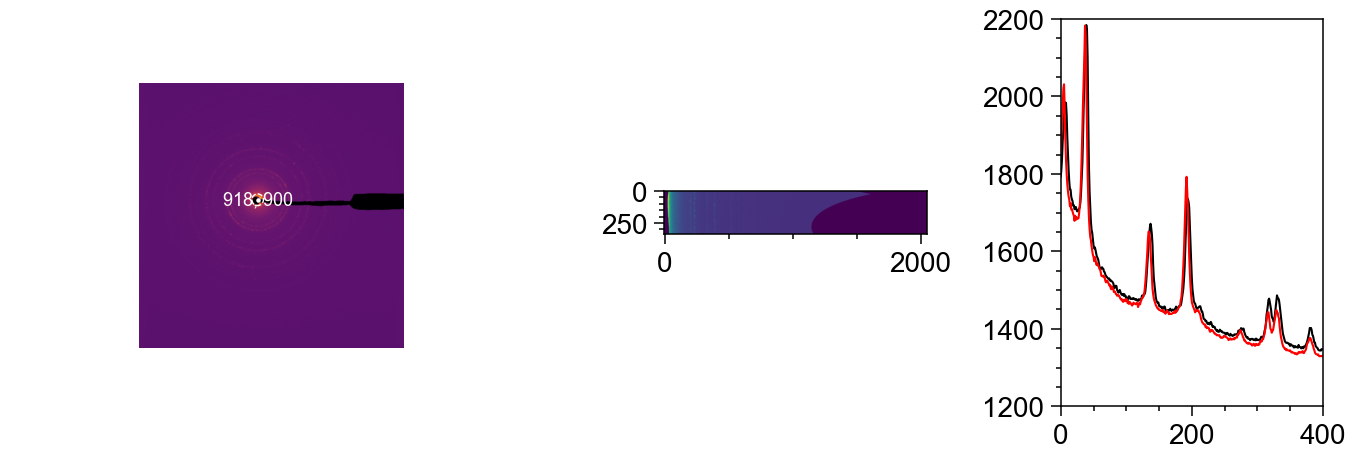

In [103]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from tifffile import tifffile
directory = r"Z:\ActualWork\Victor\raw_data\F30\20250822\tif\Au_560mm_10s_noscale.tif"
img = tifffile.imread(directory)

masking = True
side = False
b = 2

analysis = ImageAnalysis()
processing = ImageProcessing(directory)

def pad_image_for_hough(image, pad_width=512, mode='constant'):
    padded_image = np.pad(image, ((pad_width, pad_width), (pad_width, pad_width)), mode=mode)
    return padded_image, pad_width

# Apply padding

offset = 0
if side:
    img_padded, offset = pad_image_for_hough(img, pad_width=256)

#Achar o centro do difratograma

if side:
    cx, cy, r, thre, blur, edges = analysis.find_center(img_padded, r=1, R=5000, threshold=80, niter=10, kappa=0, anisotropic=False)
else:
    cx, cy, r, *_ = analysis.find_center(img, r=1, R=5000, threshold=60, niter=10, kappa=0, anisotropic=False)


circle1 = Circle((cx, cy), r, fill=False, color='white', linestyle='--')

if masking:
    beamstop_mask = processing.load_mask(r"E:\data_processing\data\processed\epdf\MASKS\mask_f30.tif")
    if b == 1 or beamstop_mask.shape[0]==2048:
        img[beamstop_mask == 255] = 0
    elif beamstop_mask.shape[0]==4096:
        def bin_2d_by_2(arr):
            shape = arr.shape
            assert shape[0] % 2 == 0 and shape[1] % 2 == 0

            return arr.reshape(shape[0]//2, 2, shape[1]//2, 2).mean(axis=(1, 3))

        binned_mask = bin_2d_by_2(beamstop_mask)
        img[binned_mask == 255] = 0

    # defects_mask = processing.load_mask('/home/ABTLUS/victor.secco/data_processing/ED/MASKS/test_defects_mask.png')
    # img[defects_mask == 255] = 0


center = cx,cy

corners = np.array([
    [0, 0],
    [0, img.shape[1] - 1],
    [img.shape[0] - 1, 0],
    [img.shape[0] - 1, img.shape[1] - 1]
])

distances = np.linalg.norm(corners - center+offset, axis=1)

binning = max(img.shape[0], distances.max())


# Transormada polar e a integração azimuta


fig, ax = plt.subplots(1, 3, figsize=(14, 5), gridspec_kw={'width_ratios': [2, 1, 1]})


if side:
    ax[0].imshow(img_padded**(1/2), cmap='inferno')
else:
    ax[0].imshow(img**(1/2), cmap='inferno')
ax[0].scatter(cx, cy, s=5, color='white')
ax[0].add_patch(circle1)
ax[0].axis('off')
ax[0].text(cx, cy,
           f'{cx:.0f}, {cy:.0f}',  # format as float with 2 decimal places
           color='white', fontsize=13, ha='center', va='center')



data, polar_image, masked_image = analysis.azimuth_integration_cv2(img, center=[cx-offset, cy-offset], binning=binning)

ang1 = 40
ang2= 100

start = int(ang1*binning/360)
end =  int(ang2*binning/360)

ax[1].imshow(polar_image[start + 180:end + 180])
ax[1].imshow(polar_image[start:end])


ax[2].plot(polar_image[250:750,].mean(axis=0)[200:600])
ax[2].plot(polar_image[1250:1750,].mean(axis=0)[200:600])

plt.tight_layout()
plt.show()

import pandas as pd
from pathlib import Path

p = Path(r"C:\Users\seccolev\data_processing\data\processed\ePDF\Au\20250910")

if not p.exists():
    p.mkdir(parents=True)
    print("Created:", p)


roi = pd.DataFrame(np.array([data]).T)
roi.to_csv(p / "b2_1s.csv", index=None, sep="\t")

In [29]:
peaks

q_spacings = [0,2.481276846439156,
                2.9925327245699958,
                4.232080824309469]

dq_values = [q_spacings[x]/peaks[x] for x in range(len(peaks))]
dq_values.pop(0)
dq = np.array(dq_values).mean() 
# dq = dq_values[0] 


<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
C:\Users\seccolev\AppData\Local\Temp\ipykernel_18604\3887091233.py:9: SyntaxWarning: invalid escape sequence '\s'
  theta = pd.read_csv(p, sep = "\s+")["2θ"].values
C:\Users\seccolev\AppData\Local\Temp\ipykernel_18604\3887091233.py:10: SyntaxWarning: invalid escape sequence '\s'
  I = pd.read_csv(p, sep = "\s+")["I"].values


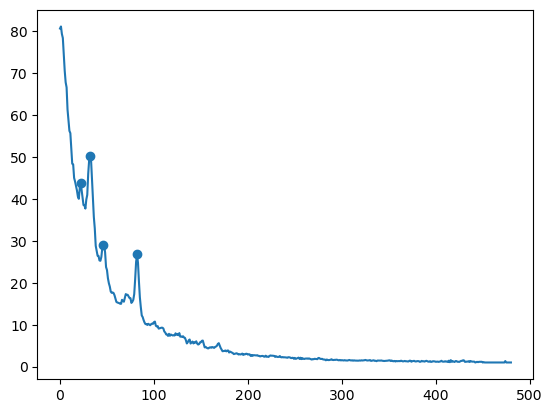

2.11604058456088
2.481276846439156
2.9925327245699958
3.6650894603950857
3.8874139527598537
4.232080824309469
4.905837817151432
5.746520235250648
5.9850656346214235
6.4790236027050145
7.136736022351472
7.3301785746696995


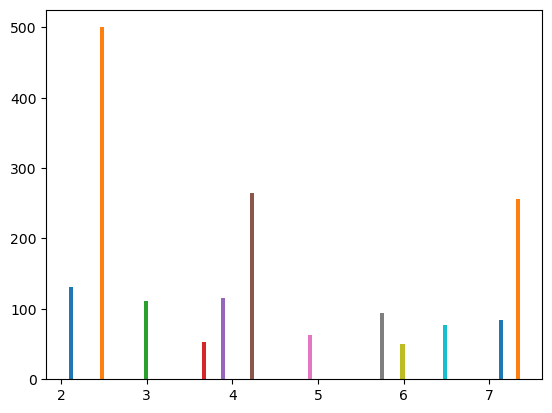

In [25]:
from scipy.signal import find_peaks
from mypackages.funcs import *

p = Path(r"E:\data_processing\data\crystallographic_db\Fe3O4_1513304.txt")


# theta = pd.read_csv(p, sep = "\s+")["d(Å)"].values

theta = pd.read_csv(p, sep = "\s+")["2θ"].values
I = pd.read_csv(p, sep = "\s+")["I"].values


q_refle = two_theta_to_q(theta, wavelength=1.54059)

y_fit = data[30:]

peaks, _ = find_peaks(y_fit, prominence=3.8)

# start = 0.2
# q_exp = np.arange(start,start+ len(y_fit)*dq, dq)

plt.plot(y_fit)
plt.scatter(peaks, y_fit[peaks])
plt.show()

for i, r in enumerate(I):
    if r>10:
        plt.bar(q_refle[i], r*5, width=0.05)
        print(q_refle[i])
plt.show()




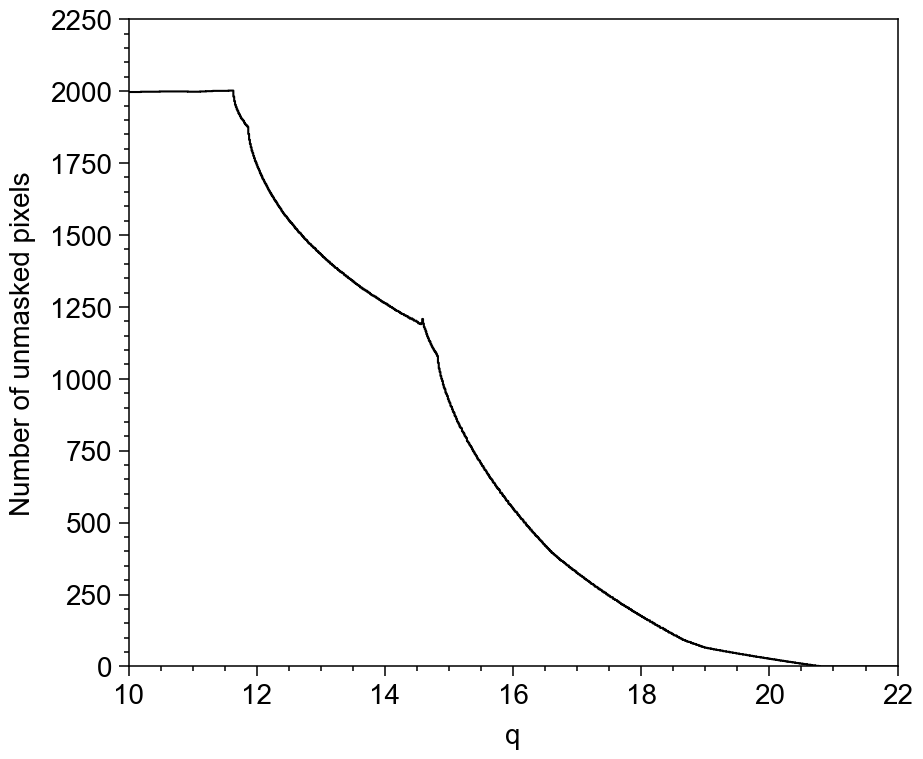

In [104]:
from mypackages.plot_style import set_plot_style

set_plot_style()

nrows, ncols = masked_image.shape

dq = 0.012926118827172666
# x indices in pixels → q values
x_pixels = np.arange(ncols)
q_axis = x_pixels * dq

# map q for each pixel column
q_map = np.repeat(q_axis[None, :], nrows, axis=0)

# flatten arrays and apply mask
valid_q = q_map[~masked_image.mask]

# histogram in q=10–19
bins = np.arange(10, 22 + dq, dq)
hist, bin_edges = np.histogram(valid_q, bins=bins)

plt.plot(bin_edges[:-1], hist, drawstyle="steps-mid")
plt.xlabel("q")
plt.ylabel("Number of unmasked pixels")
plt.show()

p = Path("Z:\\ActualWork\\Victor\\processed_data") / "hist_spirit_f30.csv"

pd.DataFrame(np.array([hist, bin_edges[:-1]]).T).to_csv(p)

18.97470878941541 Z:\ActualWork\Victor\processed_data\hist_timepix x 4.csv
21.992221054265777 Z:\ActualWork\Victor\processed_data\hist_spirit_250 mm.csv


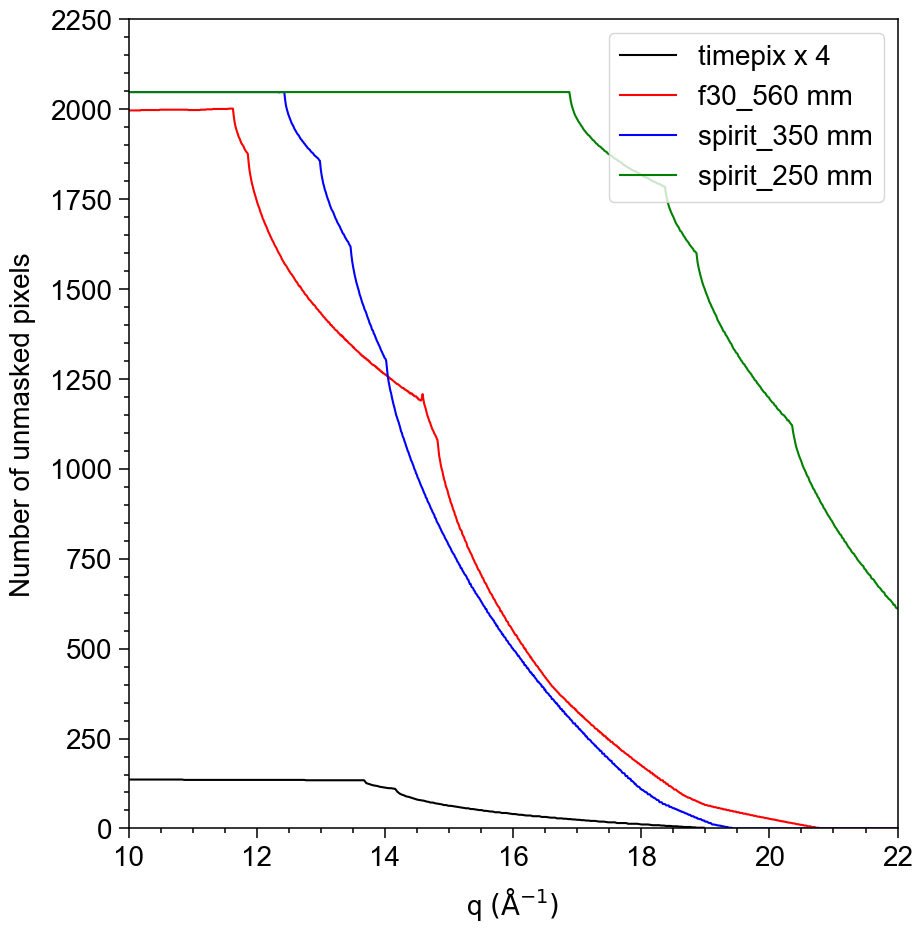

In [136]:
path_hists = [x for x in p.parent.iterdir() if str(x.name).startswith("hist")]

plt.figure(figsize=(10,10))

for p in path_hists:
    hist = pd.read_csv(p, index_col=0)["0"].values
    bins = pd.read_csv(p, index_col=0)["1"].values
    if hist[bins.argmax()]!=0:
        print(bins.max(), p)
    plt.plot(bins, hist, label = p.name[5:-4])


plt.xlabel(r"q $\mathrm{(Å^{-1})}$")
plt.ylabel("Number of unmasked pixels")
plt.xlim(10,22)
plt.legend()
plt.show()

np.float64(18.97470878941541)

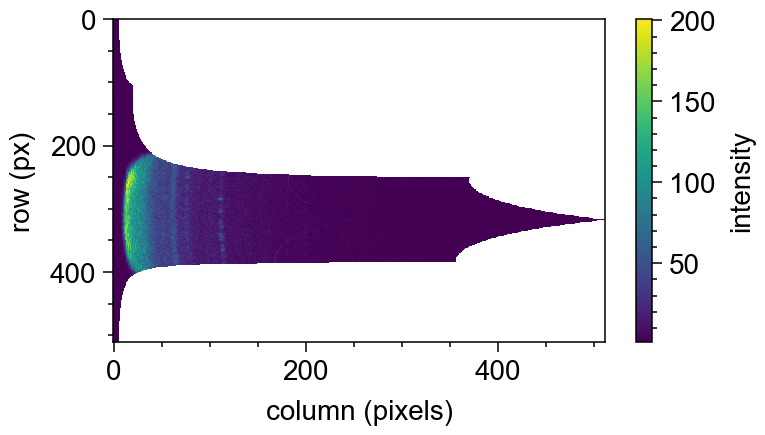

In [83]:
nrows, ncols = masked_image.shape
qmin = 1 * dq
qmax = (ncols + 1) * dq

plt.figure(figsize=(8,4))
plt.imshow(masked_image, aspect='auto', interpolation='nearest')
plt.xlabel(r"column (pixels)")
plt.ylabel("row (px)")
plt.colorbar(label="intensity")
# plt.xticks([x for x in np.arange(1,18,2)])
# plt.xlim(1, 18)  # optional: focus on your q-range
plt.show()

In [103]:
bin_edges_bspirit25, hist_bspirit25 = bin_edges, hist

NameError: name 'bin_edges_bspirit25' is not defined

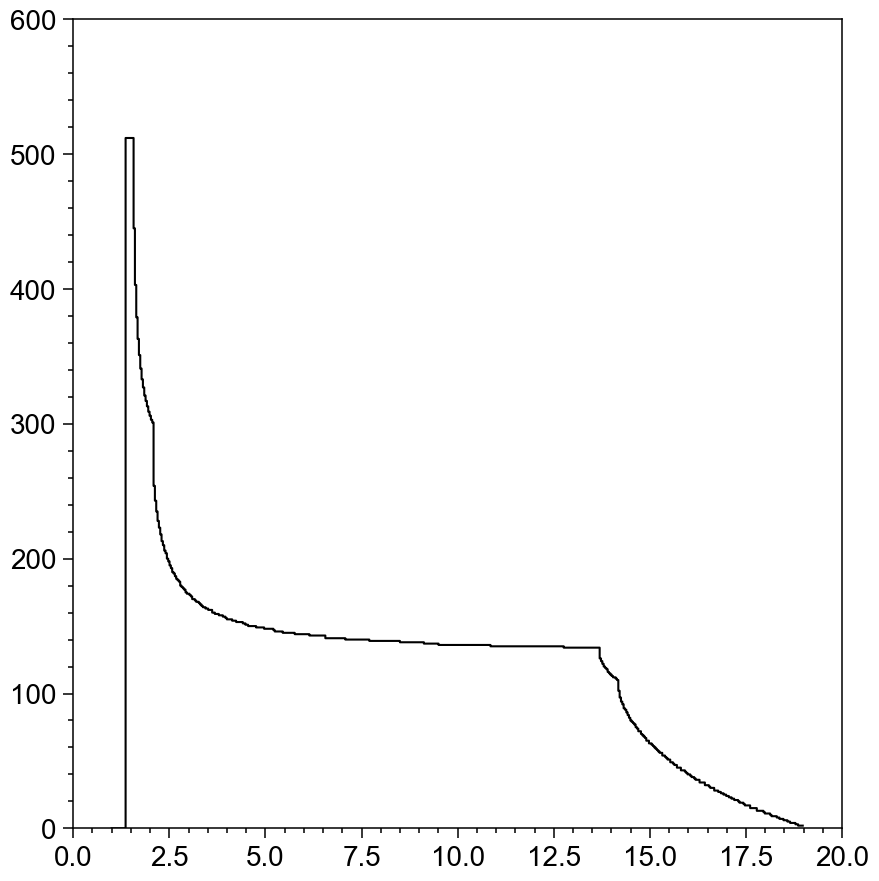

In [58]:
from mypackages.plot_style import set_plot_style

set_plot_style()

plt.figure(figsize=(10,10))

plt.plot(bin_edges[:-1], hist, drawstyle="steps-mid", label="spirit 250 mm")
plt.plot(bin_edges_bspirit25[:-1], hist_bspirit25, drawstyle="steps-mid", label="spirit 250 mm")
plt.plot(bin_edges_bssp[:-1], hist_bssp, drawstyle="steps-mid", label="beamstopper spirit 250 mm")
plt.plot(bin_edges_f30[:-1], hist_f30, drawstyle="steps-mid",  label = "f30 560 mm")
plt.plot(bin_edges_sp[:-1], hist_sp, drawstyle="steps-mid", label = "side beam spirit 500 mm")


# plt.yticks(np.arange(hist.min(),hist.max()+100, 200))
# plt.ylim(hist.min(),hist.max()+100)
plt.legend()
plt.xlabel(r"q $\mathrm{(Å^{-1})}$")
plt.ylabel("Number of unmasked pixels")
plt.show()

In [23]:
output_path = r"C:\Users\seccolev\data_processing\data\processed\ePDF\In2O3\20250815"

np.save(os.path.join(output_path, "in2o3_polar_image.npy"), polar_image)

## Azimuthal average and saving

Plotting and saving the intensity of the azimuthally averaged diffraction. The x-axis is not saved as it is not 

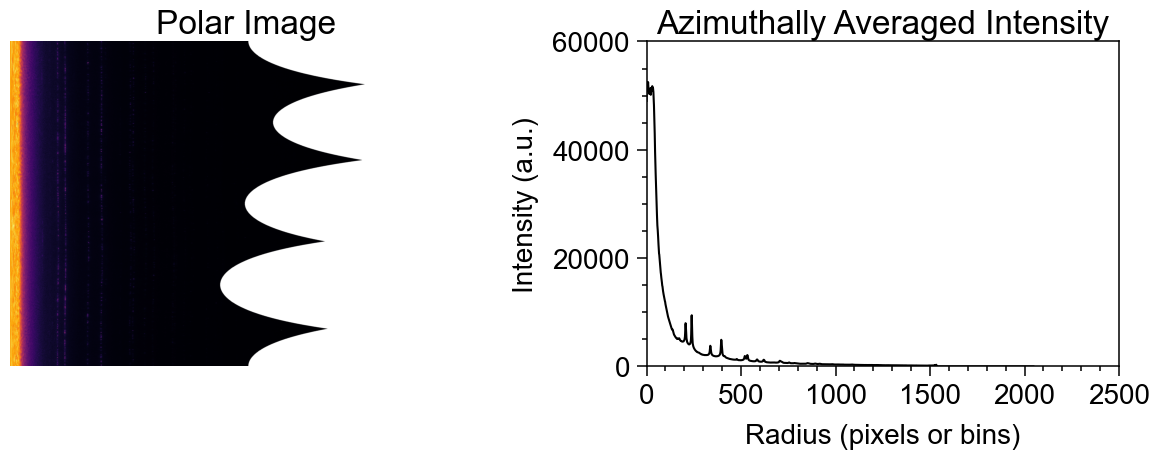

In [23]:
import matplotlib.pyplot as plt

# --- Mask the beamstopper and defects ---
processing = ImageProcessing("")

# Apply beamstopper mask
#mask = processing.load_mask('/home/ABTLUS/victor.secco/data_processing/ED/MASKS/mask_titan.tif')
#img[mask == 255] = -100

# Apply defects mask
#mask = processing.load_mask('/home/ABTLUS/victor.secco/data_processing/ED/MASKS/test_defects_mask.png')
#img[mask == 255] = -100

# --- Perform azimuthal integration ---
data, polar_image, masked_image = analysis.azimuth_integration_cv2(
    img,
    center=[cx, cy+1],
    binning=binning
)

# --- Plot polar image and integrated intensity ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Left: polar transformation
ax[0].imshow(masked_image, cmap='inferno', aspect='auto')
ax[0].set_title("Polar Image")
ax[0].axis('off')

# Right: 1D intensity plot
ax[1].plot(data)
ax[1].set_title("Azimuthally Averaged Intensity")
ax[1].set_xlabel("Radius (pixels or bins)")
ax[1].set_ylabel("Intensity (a.u.)")

plt.tight_layout()
plt.show()


In [61]:
from mypackages.funcs import *

pos1 = np.asarray(pos1, dtype=float)
pos2 = np.asarray(pos2, dtype=float)

pos1_d = q_to_d(pos1)
pos2_d = q_to_d(pos2)

diffs_d = pos1_d - pos2_d

print(pos1_d, pos2_d)


# a_from_d_hkl()

[2.36820704 2.04121611 1.44762804 1.23506494 0.93817433 0.91529203] [2.36466912 2.04087625 1.44237882 1.22962794 0.93507828 0.91083551]


In [94]:
import pandas as pd
from pathlib import Path

p = Path(r"C:\Users\seccolev\data_processing\data\processed\ePDF\Au\20250910")

if not p.exists():
    p.mkdir(parents=True)
    print("Created:", p)


roi = pd.DataFrame(np.array([data]).T)
roi.to_csv(p / "b2_1s.csv", index=None, sep="\t")